In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier

In [2]:
df=pd.read_csv('steam.csv')
df.head()

,appid,name,release_date,english,developer,publisher,platforms,required_age,categories,genres,steamspy_tags,achievements,positive_ratings,negative_ratings,average_playtime,median_playtime,owners,price
0,10,Counter-Strike,2000-11-01,1,Valve,Valve,windows;mac;linux,0,Multi-player;Online Multi-Player;Local Multi-P...,Action,Action;FPS;Multiplayer,0,124534,3339,17612,317,10000000-20000000,7.19
1,20,Team Fortress Classic,1999-04-01,1,Valve,Valve,windows;mac;linux,0,Multi-player;Online Multi-Player;Local Multi-P...,Action,Action;FPS;Multiplayer,0,3318,633,277,62,5000000-10000000,3.99
2,30,Day of Defeat,2003-05-01,1,Valve,Valve,windows;mac;linux,0,Multi-player;Valve Anti-Cheat enabled,Action,FPS;World War II;Multiplayer,0,3416,398,187,34,5000000-10000000,3.99
3,40,Deathmatch Classic,2001-06-01,1,Valve,Valve,windows;mac;linux,0,Multi-player;Online Multi-Player;Local Multi-P...,Action,Action;FPS;Multiplayer,0,1273,267,258,184,5000000-10000000,3.99
4,50,Half-Life: Opposing Force,1999-11-01,1,Gearbox Software,Valve,windows;mac;linux,0,Single-player;Multi-player;Valve Anti-Cheat en...,Action,FPS;Action;Sci-fi,0,5250,288,624,415,5000000-10000000,3.99


In [39]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27075 entries, 0 to 27074
Data columns (total 69 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   release_date                27075 non-null  int64  
 1   english                     27075 non-null  int64  
 2   required_age                27075 non-null  int64  
 3   average_playtime            27075 non-null  int64  
 4   median_playtime             27075 non-null  int64  
 5   owners                      27075 non-null  float64
 6   price                       27075 non-null  float64
 7   target                      27075 non-null  int64  
 8   Accounting                  27075 non-null  int64  
 9   Action                      27075 non-null  int64  
 10  Adventure                   27075 non-null  int64  
 11  Animation & Modeling        27075 non-null  int64  
 12  Audio Production            27075 non-null  int64  
 13  Casual                      270

In [3]:
# Creating target column
df['rating_ratio'] = df['positive_ratings'] / (df['positive_ratings'] + df['negative_ratings'])
df['target'] = (df['rating_ratio'] >= 0.7).astype(int)
# 1 = Good game (70%+ positive), 0 = Bad game

print(df['target'].value_counts())

target
1    16304
0    10771
Name: count, dtype: int64


In [4]:
df['owners'] = df['owners'].apply(lambda x:
    (int(x.split('-')[0]) + int(x.split('-')[1])) / 2)

In [6]:
df['genres'].unique()

array(['Action', 'Action;Free to Play', 'Action;Free to Play;Strategy',
       ...,
       'Action;Adventure;Indie;Massively Multiplayer;RPG;Strategy;Early Access',
       'Action;Adventure;Casual;Free to Play;Indie;RPG;Simulation;Sports;Strategy',
       'Casual;Free to Play;Massively Multiplayer;RPG;Early Access'],
      dtype=object)

In [7]:

mlb = MultiLabelBinarizer()

# Split genres by ';' and convert to numbers
genres_encoded = mlb.fit_transform(df['genres'].str.split(';'))
genres_df = pd.DataFrame(genres_encoded, columns=mlb.classes_, index=df.index)

# Add to main dataframe
df = pd.concat([df, genres_df], axis=1)

# Drop original genres column
df.drop(columns=['genres'], inplace=True)

print(df.shape)

(27075, 48)


In [8]:
df.drop(columns=['appid', 'name','developer','publisher','achievements','steamspy_tags'], inplace=True)

In [9]:
df['release_date'] = pd.to_datetime(df['release_date']).dt.year

In [10]:
platforms_encoded=mlb.fit_transform(df['platforms'].str.split(';'))
platforms_df=pd.DataFrame(platforms_encoded,columns=mlb.classes_,index=df.index)
df=pd.concat([df,platforms_df],axis=1)
df.drop(columns=['platforms'],inplace=True)
print(df.shape)

(27075, 44)


In [12]:
categories_encoded=mlb.fit_transform(df['categories'].str.split(';'))
categories_df=pd.DataFrame(categories_encoded,columns=mlb.classes_,index=df.index)
df=pd.concat([df,categories_df],axis=1)
df.drop(columns=['categories'],inplace=True)
print(df.shape)

(27075, 72)


In [14]:
df['release_date'] = df['release_date'].astype('int64')

In [15]:
df.drop(columns=['positive_ratings', 'negative_ratings'], inplace=True)

In [16]:
df.drop(columns=['rating_ratio'], inplace=True)

In [17]:
from sklearn.utils import resample

# Separate classes
df_majority = df[df['target'] == 1]
df_minority = df[df['target'] == 0]

# Downsample majority class
df_majority_downsampled = resample(df_majority,
                                   replace=False,
                                   n_samples=len(df_minority),
                                   random_state=42)

# Combine
df_balanced = pd.concat([df_majority_downsampled, df_minority])

print(df_balanced['target'].value_counts())

target
1    10771
0    10771
Name: count, dtype: int64


In [18]:
X = df_balanced.drop(columns=['target'])
y = df_balanced['target']

In [19]:

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [20]:


lr = LogisticRegression(max_iter=1000)
lr.fit(X_train_scaled, y_train)
lr_pred = lr.predict(X_test_scaled)

print("Logistic Regression Accuracy:", accuracy_score(y_test, lr_pred))
print("Logistic Regression Results:")
print(f"Accuracy: {accuracy_score(y_test, lr_pred):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, lr_pred))

Logistic Regression Accuracy: 0.6261313529821304
Logistic Regression Results:
Accuracy: 0.6261

Classification Report:
              precision    recall  f1-score   support

           0       0.61      0.69      0.65      2166
           1       0.64      0.56      0.60      2143

    accuracy                           0.63      4309
   macro avg       0.63      0.63      0.62      4309
weighted avg       0.63      0.63      0.62      4309



In [32]:


rf = RandomForestClassifier(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)

print("Random Forest Results:")
print(f"Accuracy: {accuracy_score(y_test, rf_pred):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, rf_pred))

Random Forest Results:
Accuracy: 0.6424

Classification Report:
              precision    recall  f1-score   support

           0       0.65      0.64      0.64      2166
           1       0.64      0.65      0.64      2143

    accuracy                           0.64      4309
   macro avg       0.64      0.64      0.64      4309
weighted avg       0.64      0.64      0.64      4309



In [31]:
xgb = XGBClassifier(
    random_state=42,
    n_estimators=250,
    max_depth=6,
    learning_rate=0.1
)
xgb.fit(X_train, y_train)
xgb_pred = xgb.predict(X_test)

print("XGBoost Results:")
print(f"Accuracy: {accuracy_score(y_test, xgb_pred):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, xgb_pred))

XGBoost Results:
Accuracy: 0.6565

Classification Report:
              precision    recall  f1-score   support

           0       0.65      0.68      0.67      2166
           1       0.66      0.63      0.65      2143

    accuracy                           0.66      4309
   macro avg       0.66      0.66      0.66      4309
weighted avg       0.66      0.66      0.66      4309



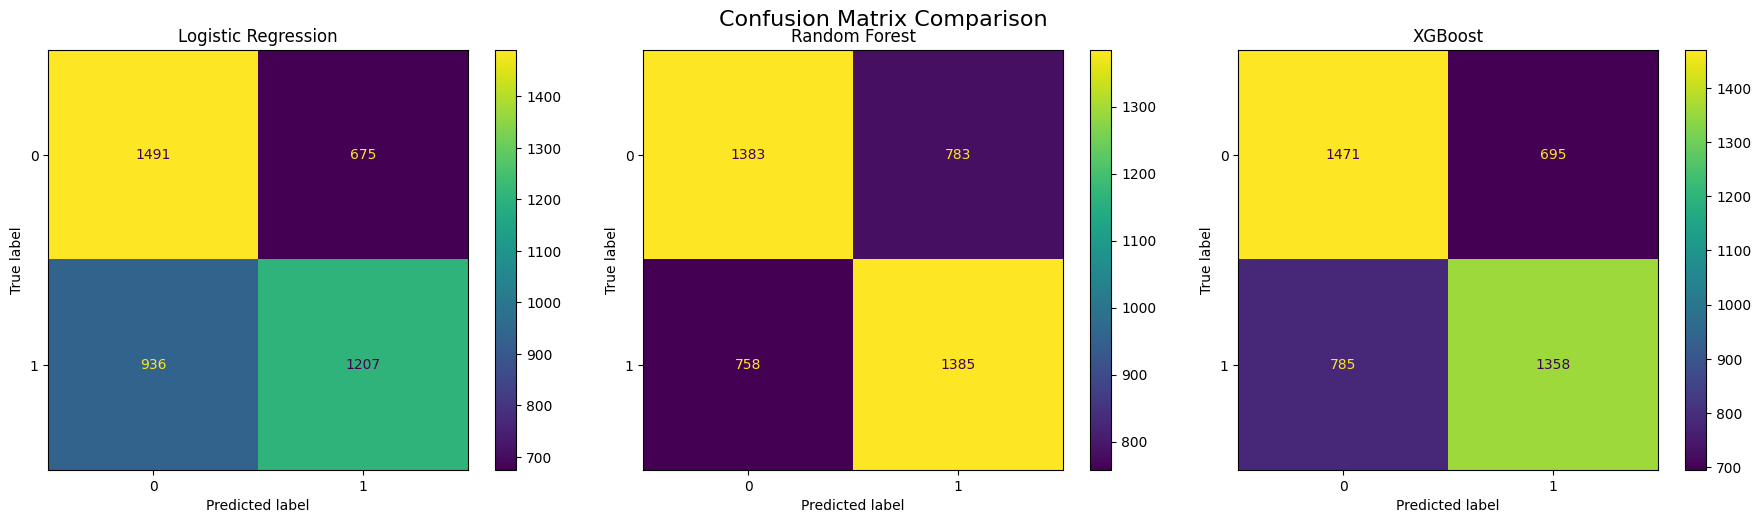

In [35]:
import seaborn as sns
from sklearn.metrics import ConfusionMatrixDisplay

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Logistic Regression
ConfusionMatrixDisplay.from_predictions(y_test, lr_pred, ax=axes[0])
axes[0].set_title('Logistic Regression')

# Random Forest
ConfusionMatrixDisplay.from_predictions(y_test, rf_pred, ax=axes[1])
axes[1].set_title('Random Forest')

# XGBoost
ConfusionMatrixDisplay.from_predictions(y_test, xgb_pred, ax=axes[2])
axes[2].set_title('XGBoost')

plt.suptitle('Confusion Matrix Comparison', fontsize=16)
plt.tight_layout()
plt.show()

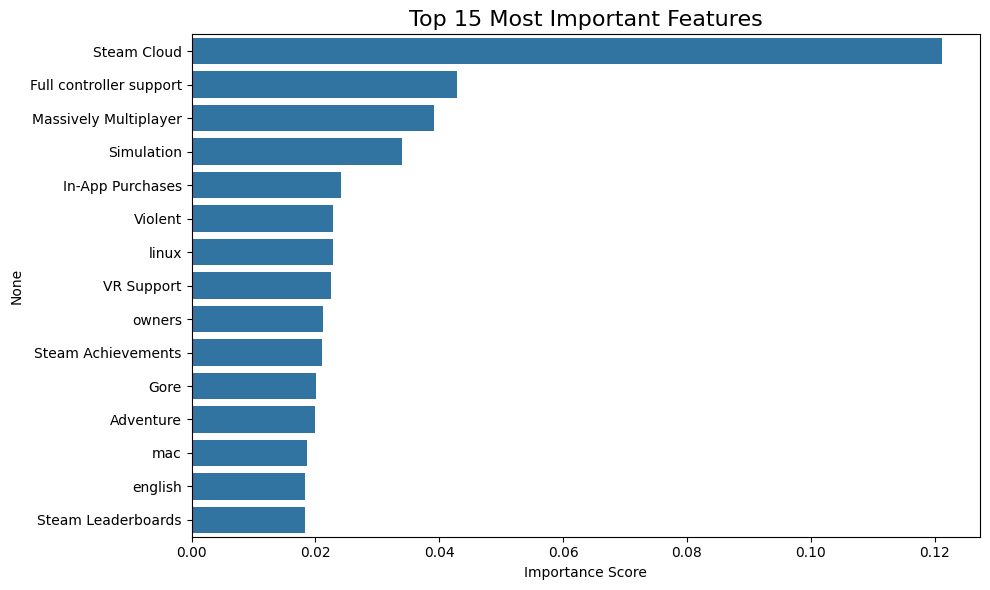

In [36]:
feature_importance = pd.Series(xgb.feature_importances_, index=X.columns)

# Top 15 most important features
top_features = feature_importance.nlargest(15)

plt.figure(figsize=(10, 6))
sns.barplot(x=top_features.values, y=top_features.index)
plt.title('Top 15 Most Important Features', fontsize=16)
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

/tmp/ipykernel_69057/1373751384.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=models, y=scores, palette='viridis')


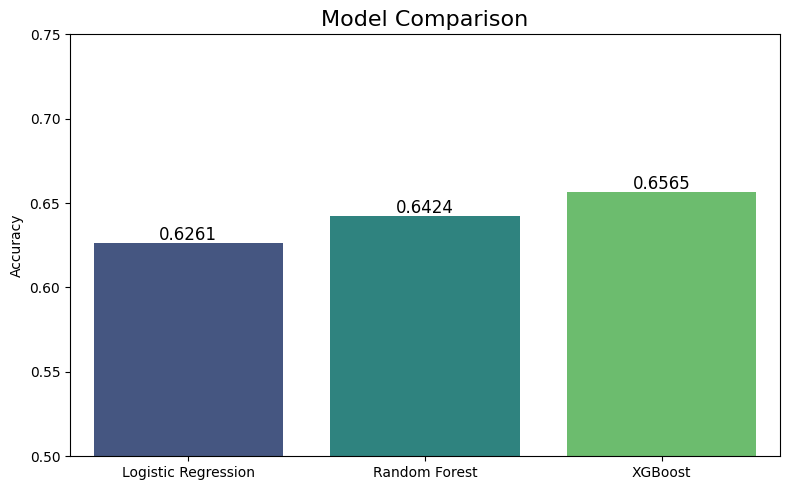

In [37]:
# Model Comparison Chart
models = ['Logistic Regression', 'Random Forest', 'XGBoost']
scores = [
    accuracy_score(y_test, lr_pred),
    accuracy_score(y_test, rf_pred),
    accuracy_score(y_test, xgb_pred)
]

plt.figure(figsize=(8, 5))
sns.barplot(x=models, y=scores, palette='viridis')
plt.title('Model Comparison', fontsize=16)
plt.ylabel('Accuracy')
plt.ylim(0.5, 0.75)

# Add accuracy values on top of bars
for i, score in enumerate(scores):
    plt.text(i, score + 0.002, f'{score:.4f}', ha='center', fontsize=12)

plt.tight_layout()
plt.show()

/tmp/ipykernel_69057/3163257032.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=models, y=scores, palette='viridis', ax=axes[0])
/tmp/ipykernel_69057/3163257032.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_features.values, y=top_features.index, palette='viridis', ax=axes[1])


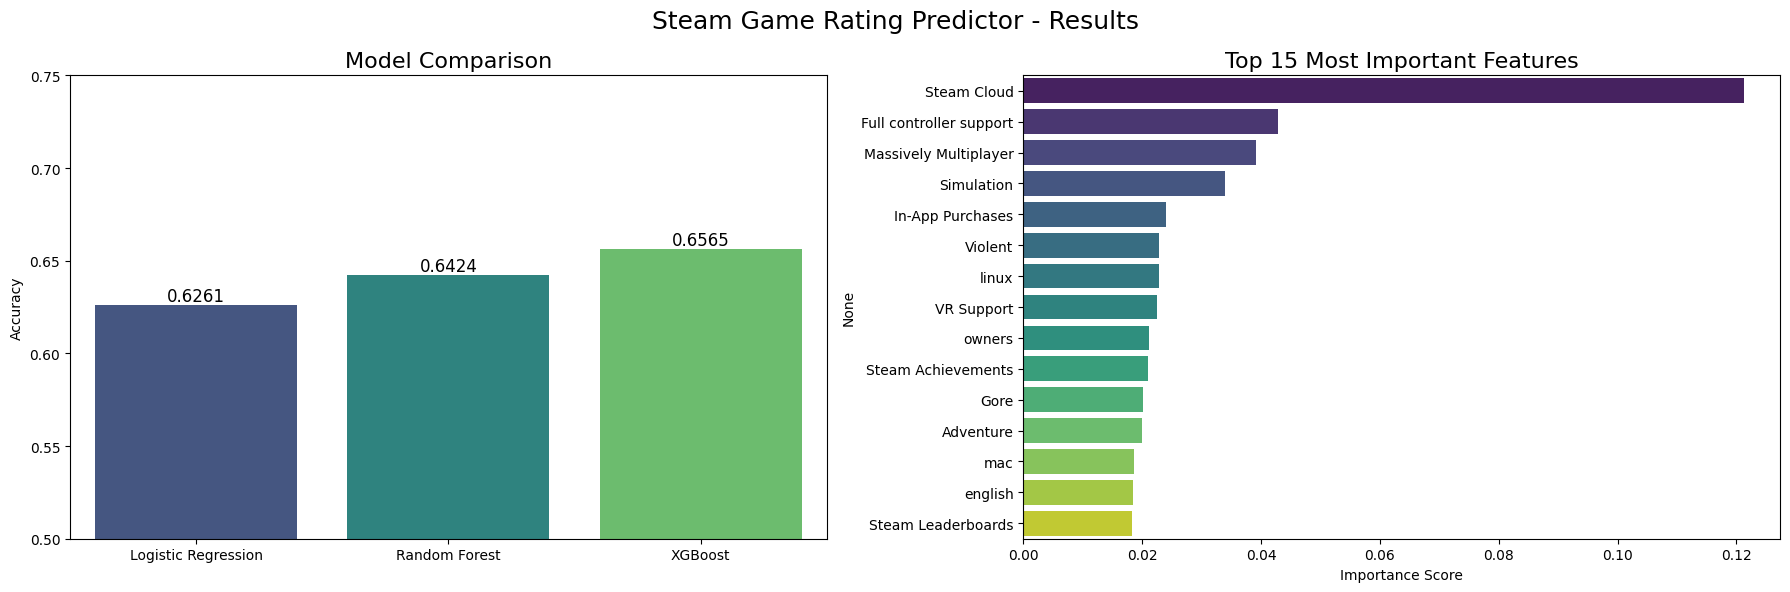

In [38]:
# Feature Importance + Model Comparison in one figure
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Model Comparison
models = ['Logistic Regression', 'Random Forest', 'XGBoost']
scores = [
    accuracy_score(y_test, lr_pred),
    accuracy_score(y_test, rf_pred),
    accuracy_score(y_test, xgb_pred)
]

sns.barplot(x=models, y=scores, palette='viridis', ax=axes[0])
axes[0].set_title('Model Comparison', fontsize=16)
axes[0].set_ylabel('Accuracy')
axes[0].set_ylim(0.5, 0.75)
for i, score in enumerate(scores):
    axes[0].text(i, score + 0.002, f'{score:.4f}', ha='center', fontsize=12)

# Feature Importance
feature_importance = pd.Series(xgb.feature_importances_, index=X.columns)
top_features = feature_importance.nlargest(15)
sns.barplot(x=top_features.values, y=top_features.index, palette='viridis', ax=axes[1])
axes[1].set_title('Top 15 Most Important Features', fontsize=16)
axes[1].set_xlabel('Importance Score')

plt.suptitle('Steam Game Rating Predictor - Results', fontsize=18)
plt.tight_layout()
plt.show()